In [1]:
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import anndata
import scgenome.plotting as pl
import matplotlib.pyplot as plt

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
data_path = "/home/vittorio.zampinetti/data/SPECTRUM"

In [3]:
def get_adata(patient_id, only_snv_data):
    signals_ad = anndata.read_h5ad(os.path.join(data_path, f"signals_SPECTRUM-OV-{patient_id}.h5"))
    print(signals_ad)
    print(signals_ad.var_names)
    sbmclone_ad = anndata.read_h5ad(os.path.join(data_path, f"sbmclone_SPECTRUM-OV-{patient_id}_snv.h5"))
    print(sbmclone_ad)
    # check how many cells match
    both_obs = signals_ad.obs_names.intersection(sbmclone_ad.obs_names)
    print(f"CN cells: {signals_ad.n_obs}, SNV cells: {sbmclone_ad.n_obs}. Intersection: {len(both_obs)}")
    if only_snv_data:
        joint_ad = signals_ad[both_obs].copy()
        joint_ad.obs['sbmclone'] = sbmclone_ad[both_obs].obs['sbmclone_cluster_id'].astype('category')
    else:
        joint_ad = signals_ad.copy()
        joint_ad.obs['sbmclone'] = 0
    return joint_ad

def show_data(patient_id, filters=None, only_snv_data=True):
    joint_ad = get_adata(patient_id, only_snv_data)
    g = pl.plot_cell_cn_matrix_fig(joint_ad, annotation_fields=['cluster_id', 'sbmclone', 'is_s_phase', 'is_normal', 'is_outlier'], cell_order_fields=['cluster_id','sbmclone'])
    vmax = np.nanpercentile(joint_ad.layers['copy'], 98)
    g = pl.plot_cell_cn_matrix_fig(joint_ad, layer_name='copy', annotation_fields=['cluster_id', 'sbmclone', 'is_s_phase', 'is_normal', 'is_outlier'], cell_order_fields=['cluster_id','sbmclone'], vmax=vmax, raw=True)
    g = pl.plot_cell_cn_matrix_fig(joint_ad, layer_name='A', annotation_fields=['cluster_id', 'sbmclone', 'is_s_phase', 'is_normal', 'is_outlier'], cell_order_fields=['cluster_id','sbmclone'])
    vmax = np.nanpercentile(joint_ad.layers['alleleA'], 98)
    g = pl.plot_cell_cn_matrix_fig(joint_ad, layer_name='alleleB', annotation_fields=['cluster_id', 'sbmclone', 'is_s_phase', 'is_normal', 'is_outlier'], cell_order_fields=['cluster_id','sbmclone'], vmax=vmax, raw=True)
    if filters is not None:
        for keep, label in filters:
            if keep:
                joint_ad = joint_ad[joint_ad.obs[label]].copy()
            else:
                joint_ad = joint_ad[~joint_ad.obs[label]].copy()

    return joint_ad

def plot_baf(patient_id, only_snv_data=True, only_first_cells=10, alpha=0.01):
    joint_ad = get_adata(patient_id, only_snv_data)
    if only_first_cells is None:
        only_first_cells = joint_ad.n_obs
    yarr = joint_ad[:only_first_cells].layers['BAF'].flatten()
    xarr = np.arange(joint_ad.n_vars).repeat(only_first_cells)
    plt.scatter(xarr, yarr, alpha=alpha)
    plt.show()

def plot_pseudobulk_baf(patient_id, only_snv_data=True, alpha=0.01):
    joint_ad = get_adata(patient_id, only_snv_data)
    Asum = np.nansum(joint_ad.layers['alleleA'], axis=0)
    Bsum = np.nansum(joint_ad.layers['alleleB'], axis=0)
    baf = Bsum / (Asum + Bsum)
    yarr = baf
    xarr = np.arange(joint_ad.n_vars)
    plt.scatter(xarr, yarr, alpha=alpha)
    plt.show()





## OV-50
~300 cells without WGD


AnnData object with n_obs × n_vars = 798 × 6087
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'library_id', 'standard_deviation_insert_size', 'fastqscreen_mouse', 'median_insert_size', 'paired_duplicate_reads', 'fastqscreen_salmon_multihit', 'is_contaminated', 'index_i5', 'sample_id', 'percent_duplicate_reads', 'img_col', 'is_control', 'fastqscreen_total_reads', 'overlap_without_dups', 'estimated_library_size', 'aligned', 'total_properly_paired', 'fastqscreen_human_multihit', 'row', 'coverage_breadth', 'total_mapped_reads', 'primer_i5', 'sample_type', 'total_r

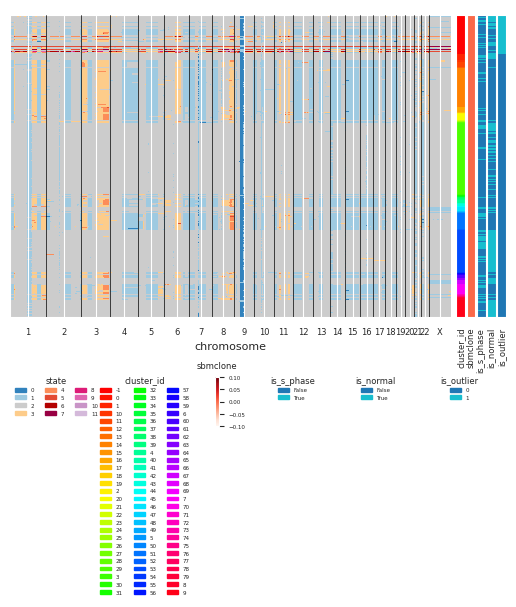

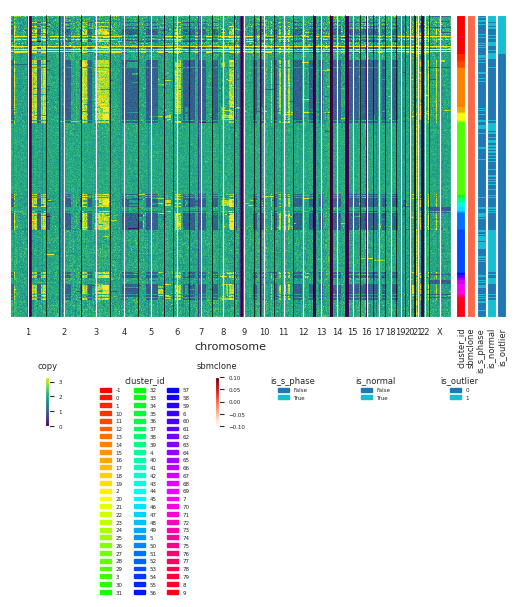

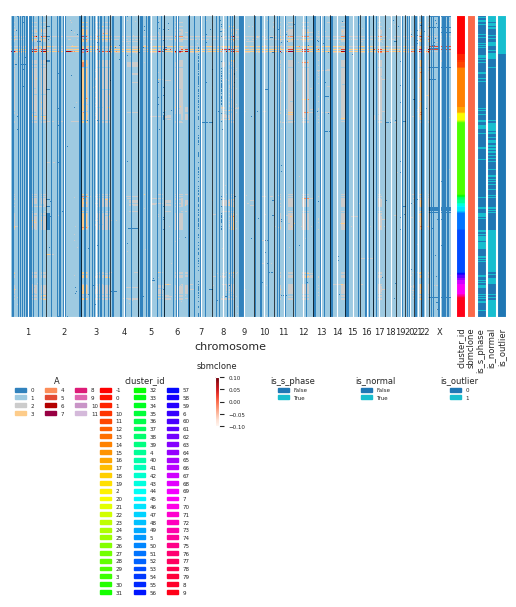

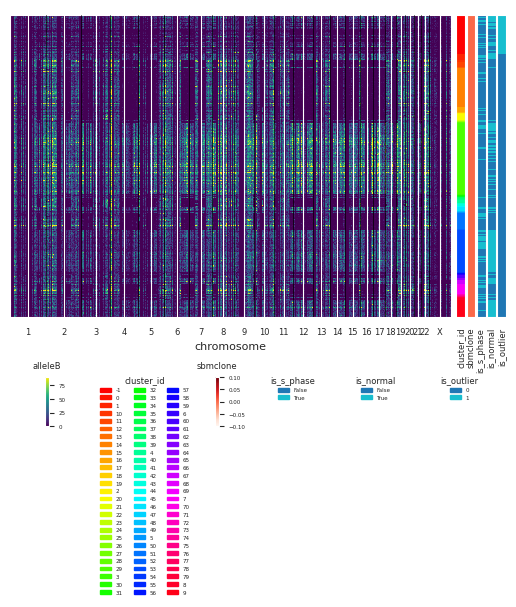

In [39]:
_ = show_data("050", only_snv_data=False)

AnnData object with n_obs × n_vars = 798 × 6087
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'library_id', 'standard_deviation_insert_size', 'fastqscreen_mouse', 'median_insert_size', 'paired_duplicate_reads', 'fastqscreen_salmon_multihit', 'is_contaminated', 'index_i5', 'sample_id', 'percent_duplicate_reads', 'img_col', 'is_control', 'fastqscreen_total_reads', 'overlap_without_dups', 'estimated_library_size', 'aligned', 'total_properly_paired', 'fastqscreen_human_multihit', 'row', 'coverage_breadth', 'total_mapped_reads', 'primer_i5', 'sample_type', 'total_r

/tmp/ipykernel_613563/986361113.py:48: RuntimeWarning: invalid value encountered in divide
  baf = Bsum / (Asum + Bsum)


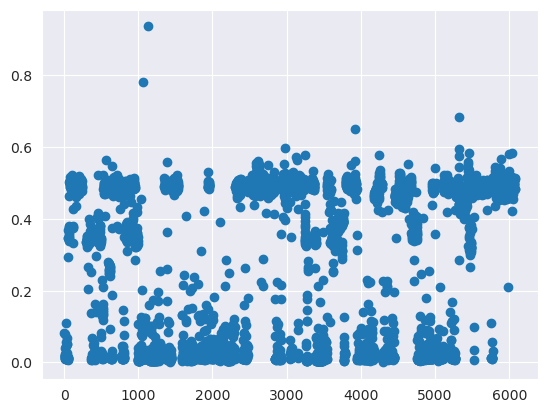

In [38]:
# plot_baf("050", only_first_cells=100, alpha=0.01)
plot_pseudobulk_baf("050", alpha=1)

## OV-80
~150 cells with few WGD


AnnData object with n_obs × n_vars = 350 × 6087
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'column', 'fastqscreen_salmon', 'percent_duplicate_reads', 'primer_i7', 'standard_deviation_insert_size', 'total_properly_paired', 'library_id', 'condition', 'total_reads', 'unpaired_duplicate_reads', 'fastqscreen_salmon_multihit', 'overlap_without_dups', 'primer_i5', 'is_control', 'paired_duplicate_reads', 'overlap_with_dups', 'coverage_depth', 'row', 'sample_id', 'paired_mapped_reads', 'fastqscreen_mouse_multihit', 'fastqscreen_human_multihit', 'total_mapped_reads',

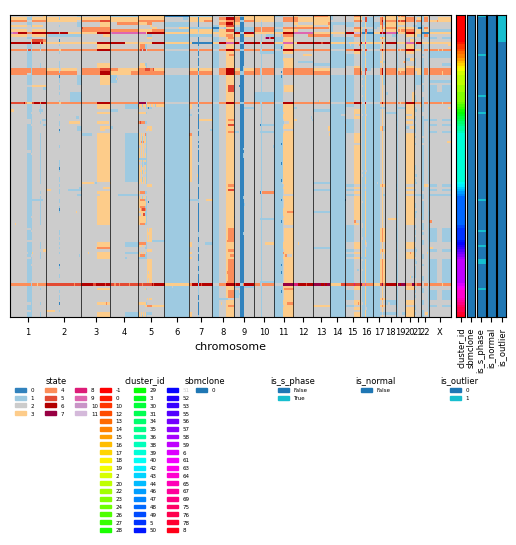

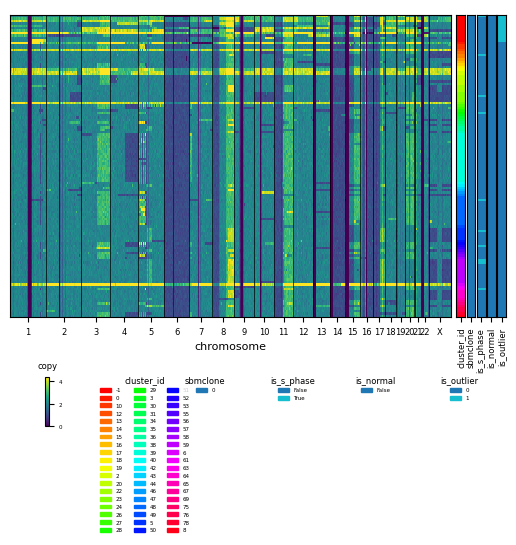

In [32]:
_ = show_data("080")

## OV-125
< 100 cells with half cells WGD



AnnData object with n_obs × n_vars = 308 × 6087
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'index_i7', 'fastqscreen_total_reads', 'paired_mapped_reads', 'fastqscreen_mouse', 'index_sequence', 'coverage_breadth', 'total_duplicate_reads', 'library_id', 'overlap_with_all_filters', 'estimated_library_size', 'column', 'coverage_depth', 'unpaired_mapped_reads', 'percent_duplicate_reads', 'condition', 'expected', 'sample_type', 'is_control', 'median_insert_size', 'standard_deviation_insert_size', 'fastqscreen_salmon_multihit', 'img_col', 'total_mapped_reads', 'fas

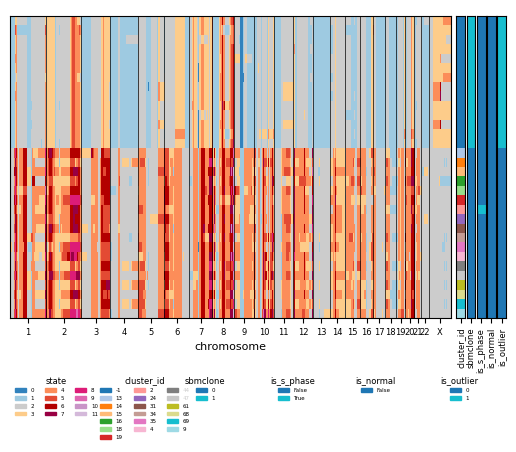

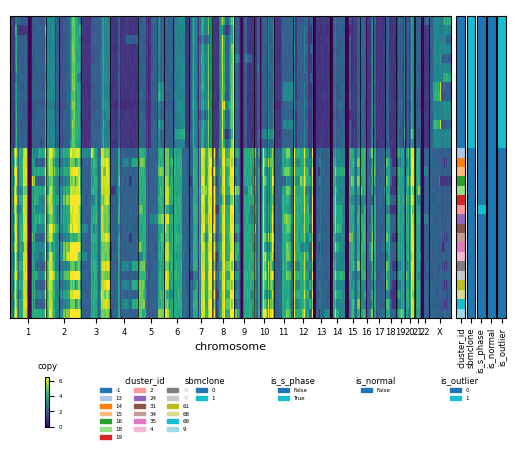

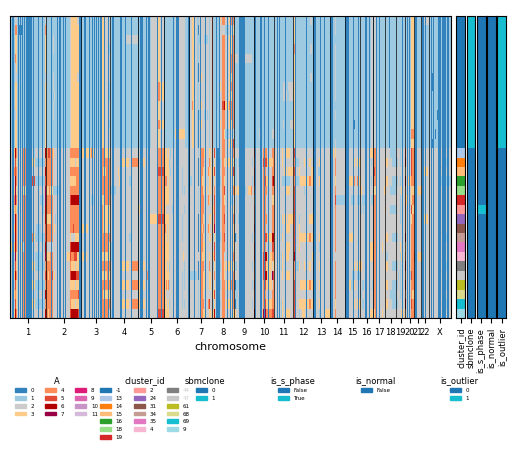

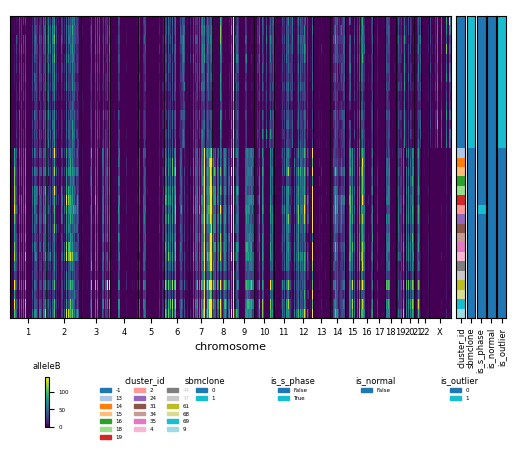

In [6]:
_ = show_data("125")

## OV-110
< 100 cells, mostly WGD


AnnData object with n_obs × n_vars = 1161 × 6087
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'index_i7', 'total_duplicate_reads', 'is_control', 'primer_i7', 'pick_met', 'index_i5', 'is_contaminated', 'percent_duplicate_reads', 'fastqscreen_total_reads', 'row', 'unpaired_mapped_reads', 'fastqscreen_mouse', 'fastqscreen_nohit', 'overlap_with_all_filters', 'unmapped_reads', 'overlap_with_all_filters_and_qual', 'overlap_without_dups', 'fastqscreen_human', 'column', 'expected', 'overlap_with_dups', 'condition', 'total_mapped_reads', 'index_sequence', 'library_id'

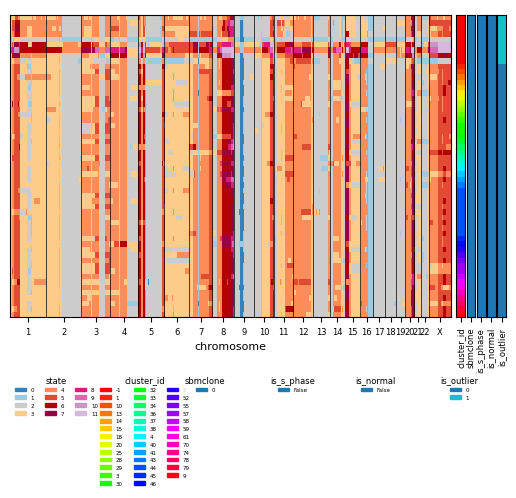

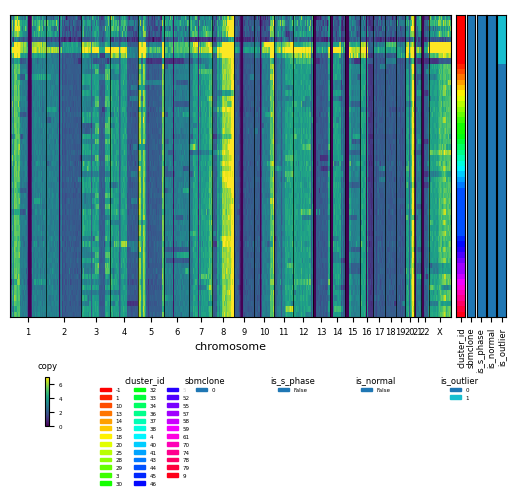

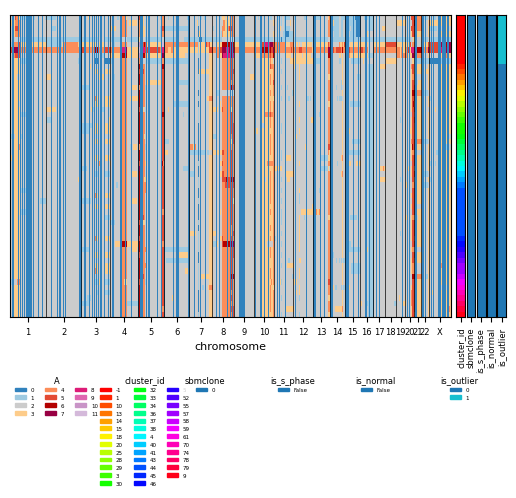

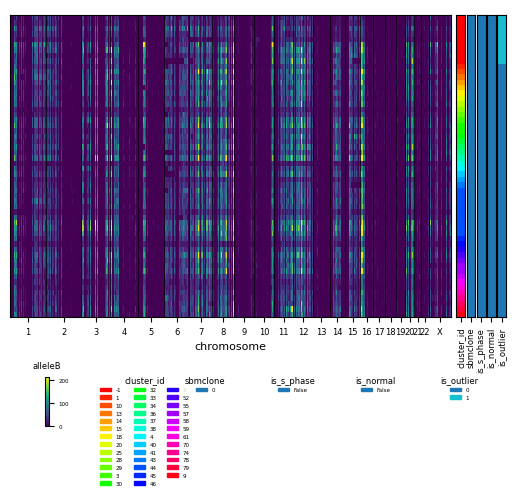

In [7]:
_ = show_data("110")

## OV-008
~100+ cells, only tetraploid WGD



AnnData object with n_obs × n_vars = 736 × 6087
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'fastqscreen_salmon', 'is_contaminated', 'mean_insert_size', 'sample_type', 'unpaired_mapped_reads', 'fastqscreen_salmon_multihit', 'total_reads', 'overlap_with_dups', 'overlap_without_dups', 'fastqscreen_human_multihit', 'library_id', 'fastqscreen_mouse_multihit', 'index_sequence', 'is_control', 'coverage_depth', 'sample_id', 'standard_deviation_insert_size', 'fastqscreen_total_reads', 'aligned', 'row', 'pick_met', 'fastqscreen_nohit', 'overlap_with_all_filters', 'co

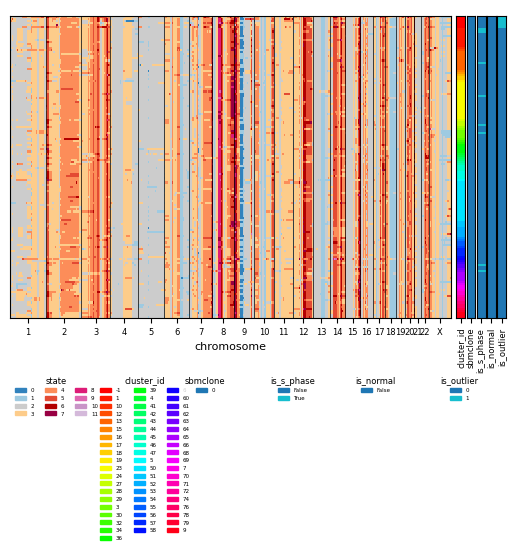

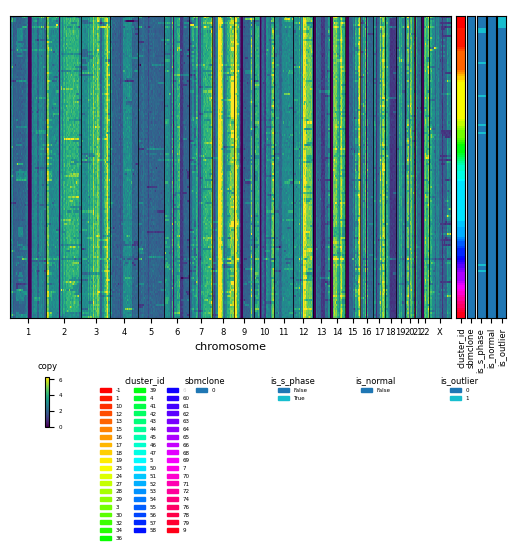

In [35]:
_ = show_data("008")

## OV-45 - plot in study
\>1000 cells, mostly wgd

